# **DX 799: Week 4 — Logistic Regression and Feature Scaling**

For Week 4, include concepts such as logistic regression and feature scaling. This homework should be submitted for peer review in the assignment titled 4.3 Peer Review: Week 4 Jupyter Notebook. Complete and submit your Jupyter Notebook homework by 11:59pm ET on Sunday. 

In [ ]:
import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, RocCurveDisplay
pd.set_option('display.max_columns', None)

---

# DIABETES DATASET

In [2]:
#DIABETES: LOAD
df_diabetes = pd.read_csv("../Datasets/diabetes_cleaned.csv")
# The first few rows
df_diabetes.iloc[0:5]

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### Diabetes: Logistic Regression and Feature Scaling

In [3]:
y_diabetes = df_diabetes["Diabetes_012"]              # 0/1/2
X_diabetes = df_diabetes.drop("Diabetes_012", axis=1)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

logit_mn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(multi_class="multinomial",
                                 solver="lbfgs", max_iter=2000))
])

acc = cross_val_score(logit_mn, X_diabetes, y_diabetes, cv=cv, scoring="accuracy")
auc = cross_val_score(logit_mn, X_diabetes, y_diabetes, cv=cv, scoring="roc_auc_ovr_weighted")

print(f"Diabetes (multiclass) - Accuracy: {acc.mean():.4f} ± {acc.std():.4f}")
print(f"Diabetes (multiclass) - ROC-AUC (OVR, weighted): {auc.mean():.4f} ± {auc.std():.4f}")


/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'm

Diabetes (multiclass) - Accuracy: 0.8465 ± 0.0014
Diabetes (multiclass) - ROC-AUC (OVR, weighted): 0.8158 ± 0.0028


---
# KIDNEY DATASET 

In [4]:
#Kidney: LOAD
df_kidney = pd.read_csv("../Datasets/Chronic_Kidney_Dsease_data.csv")
# The first few rows
df_kidney.iloc[0:5]

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryKidneyDisease,FamilyHistoryHypertension,FamilyHistoryDiabetes,PreviousAcuteKidneyInjury,UrinaryTractInfections,SystolicBP,DiastolicBP,FastingBloodSugar,HbA1c,SerumCreatinine,BUNLevels,GFR,ProteinInUrine,ACR,SerumElectrolytesSodium,SerumElectrolytesPotassium,SerumElectrolytesCalcium,SerumElectrolytesPhosphorus,HemoglobinLevels,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,ACEInhibitors,Diuretics,NSAIDsUse,Statins,AntidiabeticMedications,Edema,FatigueLevels,NauseaVomiting,MuscleCramps,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,1,71,0,0,0,2,31.069414,1,5.128112,1.676220,0.240386,4.076434,0,0,0,0,0,113,83,72.510788,9.212397,4.962531,25.605949,45.703204,0.744980,123.849426,137.652501,3.626058,10.314420,3.152648,16.114679,207.728670,85.863656,21.967957,212.095215,0,0,4.563139,1,0,0,3.563894,6.992244,4.518513,7.556302,76.076800,0,0,1,1.018824,4.966808,9.871449,1,Confidential
1,2,34,0,0,1,3,29.692119,1,18.609552,8.377574,6.503233,7.652813,1,1,0,0,0,120,67,100.848875,4.604989,3.156799,31.338166,55.784504,3.052317,88.539095,138.141335,5.332871,9.604196,2.855443,15.349205,189.450727,86.378670,87.569756,255.451314,0,0,9.097002,0,0,0,5.327336,0.356290,2.202222,6.836766,40.128498,0,0,0,3.923538,8.189275,7.161765,1,Confidential
2,3,80,1,1,0,1,37.394822,1,11.882429,9.607401,2.104828,4.392786,0,0,0,0,0,147,106,160.989441,5.432599,3.698236,39.738169,67.559032,1.157839,21.170892,142.970116,4.330891,9.885786,4.353513,13.018834,284.137622,132.269872,20.049798,251.902583,0,1,3.851249,1,0,0,4.855420,4.674069,5.967271,2.144722,92.872842,0,1,1,1.429906,7.624028,7.354632,1,Confidential
3,4,40,0,2,0,1,31.329680,0,16.020165,0.408871,6.964422,6.282274,0,0,0,0,0,117,65,188.506620,4.144466,2.868468,21.980958,33.202542,3.745871,123.779699,137.106913,3.810741,9.995894,4.016134,15.056339,235.112124,93.443669,58.260291,392.338425,0,0,7.881765,0,0,0,8.531685,5.691455,2.176387,7.077188,90.080321,0,0,0,3.226416,3.282688,6.629587,1,Confidential
4,5,43,0,1,1,2,23.726311,0,7.944146,0.780319,3.097796,4.021639,0,0,0,0,0,98,66,82.156699,4.262979,3.964877,12.216366,56.319082,2.570993,184.852046,140.627812,4.866765,8.907622,3.947907,16.690561,258.277566,171.758356,21.583213,370.523877,1,1,4.179459,1,0,0,1.422320,2.273459,6.800993,3.553118,5.258372,0,0,1,0.285466,3.849498,1.437385,1,Confidential


### Kidney: Logistic Regression and Feature Scaling

In [5]:


y_kidney = df_kidney["Diagnosis"]
X_kidney = df_kidney.drop(columns=["Diagnosis", "DoctorInCharge"])  # drop text column

cv_kidney = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

logit_k = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(solver="liblinear", max_iter=2000))
])

acc_k = cross_val_score(logit_k, X_kidney, y_kidney, cv=cv_kidney, scoring="accuracy")
auc_k = cross_val_score(logit_k, X_kidney, y_kidney, cv=cv_kidney, scoring="roc_auc")

print(f"Kidney - Accuracy: {acc_k.mean():.4f} ± {acc_k.std():.4f}")
print(f"Kidney - ROC-AUC:  {auc_k.mean():.4f} ± {auc_k.std():.4f}")



Kidney - Accuracy: 0.9213 ± 0.0105
Kidney - ROC-AUC:  0.8480 ± 0.0373


---

# HYPERTENSION DATASET

In [6]:
#HYPERTENSION: LOAD
df_hypertension = pd.read_csv("../Datasets/df_hypertension_clean.csv")
# The first few rows
df_hypertension.iloc[0:5]

,Country,Age,BMI,Cholesterol,Systolic_BP,Diastolic_BP,Smoking_Status,Alcohol_Intake,Physical_Activity_Level,Family_History,Diabetes,Stress_Level,Salt_Intake,Sleep_Duration,Heart_Rate,LDL,HDL,Triglycerides,Glucose,Gender,Education_Level,Employment_Status,Hypertension
0,UK,58,29.5,230,160,79,Never,27.9,Low,1,1,9,14.7,6.1,80,100,75,72,179,Female,Primary,Unemployed,1
1,Spain,34,36.2,201,120,84,Never,27.5,High,1,1,6,10.8,9.8,56,77,47,90,113,Male,Secondary,Unemployed,1
2,Indonesia,73,18.2,173,156,60,Current,1.8,High,1,1,5,6.5,5.2,75,162,56,81,101,Male,Primary,Employed,0
3,Canada,60,20.3,183,122,94,Never,11.6,Moderate,1,1,6,4.0,7.5,71,164,93,94,199,Female,Secondary,Retired,1
4,France,73,21.8,296,91,97,Never,29.1,Moderate,1,0,6,8.4,5.0,52,108,74,226,157,Female,Primary,Employed,1


### Hypertension: Logistic Regression and Feature Scaling

In [7]:
# one-hot all object columns once (simple and fine)
obj_cols = df_hypertension.select_dtypes(include="object").columns.tolist()
# (Optional) if Country has tons of levels and you want fewer dummies:
# obj_cols = [c for c in obj_cols if c != "Country"]

df_hyp_enc = pd.get_dummies(df_hypertension, columns=obj_cols, drop_first=True)

y_hyp = df_hyp_enc["Hypertension"]
X_hyp = df_hyp_enc.drop("Hypertension", axis=1)

cv_hyp = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

logit_h = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(solver="liblinear", max_iter=2000))
])

acc_h = cross_val_score(logit_h, X_hyp, y_hyp, cv=cv_hyp, scoring="accuracy")
auc_h = cross_val_score(logit_h, X_hyp, y_hyp, cv=cv_hyp, scoring="roc_auc")

print(f"Hypertension - Accuracy: {acc_h.mean():.4f} ± {acc_h.std():.4f}")
print(f"Hypertension - ROC-AUC:  {auc_h.mean():.4f} ± {auc_h.std():.4f}")



Hypertension - Accuracy: 0.7188 ± 0.0024
Hypertension - ROC-AUC:  0.4958 ± 0.0021


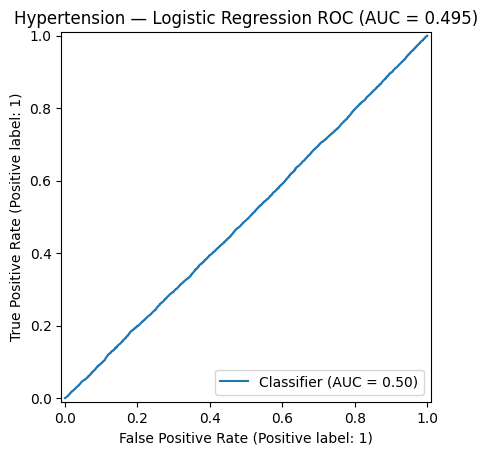

In [ ]:
# One figure: ROC curve for Hypertension (binary)


# Encode object columns once
obj_cols = df_hypertension.select_dtypes(include="object").columns.tolist()
df_hyp_enc = pd.get_dummies(df_hypertension, columns=obj_cols, drop_first=True)

X = df_hyp_enc.drop(columns=["Hypertension"])
y = df_hyp_enc["Hypertension"]

# Hold-out split for the illustrative figure
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline: scaling + logistic (no leakage)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(solver="liblinear", max_iter=2000))
])
pipe.fit(X_tr, y_tr)

# ROC curve
y_prob = pipe.predict_proba(X_te)[:, 1]
auc = roc_auc_score(y_te, y_prob)
RocCurveDisplay.from_predictions(y_te, y_prob)
plt.title(f"Hypertension — Logistic Regression ROC (AUC = {auc:.3f})")
plt.show()
